In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('placement.csv')

In [5]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [9]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

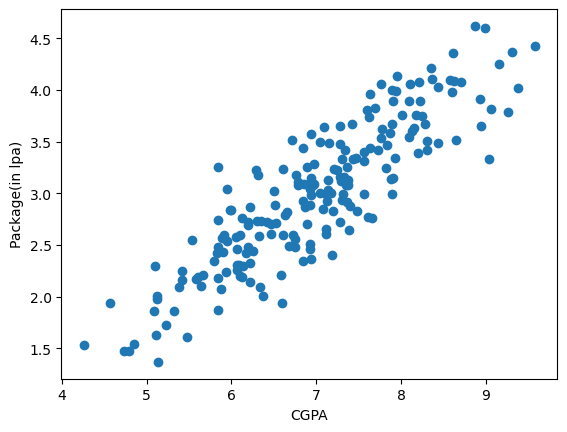

In [10]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [11]:
x = df.iloc[:,0]
y = df.iloc[:,-1]

In [12]:
x

0      6.89
1      5.12
2      7.82
3      7.42
4      6.94
       ... 
195    6.93
196    5.89
197    7.21
198    7.63
199    6.22
Name: cgpa, Length: 200, dtype: float64

In [13]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [26]:
x_train

137    7.14
163    8.93
111    5.42
123    5.10
109    7.77
       ... 
43     7.66
22     6.14
72     7.78
15     7.25
168    8.65
Name: cgpa, Length: 160, dtype: float64

In [27]:
y_train

137    3.13
163    3.91
111    2.25
123    2.30
109    4.06
       ... 
43     2.76
22     2.30
72     3.62
15     3.23
168    3.52
Name: package, Length: 160, dtype: float64

In [35]:
lr.fit(x_train.values.reshape(-1,1),y_train.values.reshape(-1,1))

LinearRegression()

In [37]:
x_train = x_train.values.reshape(-1,1)

In [34]:
lr.fit(x_train,y_train)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

Text(0, 0.5, 'Package(lpa)')

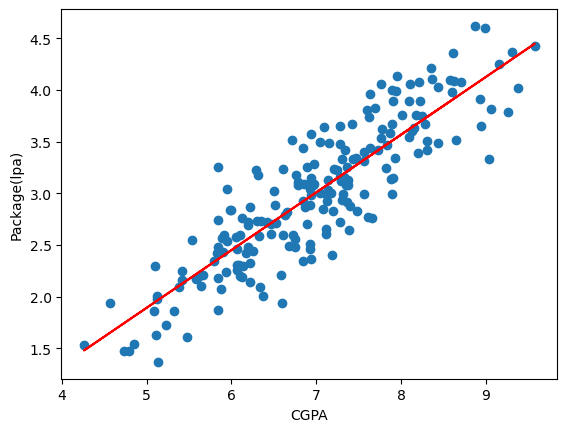

In [38]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train, lr.predict(x_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(lpa)')

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
x_test = x_test.values.reshape(-1,1)
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [48]:
y_pred = lr.predict(x_test)

In [45]:
y_test

array([[4.1 ],
       [3.49],
       [2.08],
       [2.33],
       [1.94],
       [1.48],
       [1.86],
       [3.09],
       [4.21],
       [2.87],
       [3.65],
       [4.  ],
       [2.89],
       [2.6 ],
       [2.99],
       [3.25],
       [1.86],
       [3.67],
       [2.37],
       [3.42],
       [2.48],
       [3.65],
       [2.6 ],
       [2.83],
       [4.08],
       [2.56],
       [3.58],
       [3.81],
       [4.09],
       [2.01],
       [3.63],
       [2.92],
       [3.51],
       [1.94],
       [2.21],
       [3.34],
       [3.34],
       [3.23],
       [2.01],
       [2.61]])

In [49]:
y_pred

array([[3.89111601],
       [3.09324469],
       [2.38464568],
       [2.57434935],
       [1.6537286 ],
       [1.77647803],
       [2.07219258],
       [2.93143862],
       [3.76278706],
       [2.93701814],
       [4.09197872],
       [3.51170867],
       [2.97049525],
       [2.40138424],
       [3.18809652],
       [3.46707251],
       [1.94386362],
       [3.24389172],
       [2.97607477],
       [3.41685683],
       [2.55761079],
       [3.16577844],
       [2.85890486],
       [3.12114229],
       [3.68467378],
       [2.8700639 ],
       [3.49497011],
       [3.34432308],
       [3.91901361],
       [1.96060218],
       [3.65119666],
       [3.2104146 ],
       [3.74046898],
       [2.7863711 ],
       [2.78079158],
       [3.27178932],
       [3.52844723],
       [2.61340599],
       [2.65804215],
       [2.71383735]])

In [50]:
print('MAE', mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [51]:
print('MSE', mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [53]:
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [56]:
print('R2 Score', r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score 0.780730147510384


In [57]:
x_test.shape

(40, 1)

In [58]:
print('Adjusted r2 Score', 1-(((1-r2)*(40-1))/(40-1-1)))

Adjusted r2 Score 0.7749598882343415


In [59]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

In [60]:
new_df1

,cgpa,package,random_feature
0,6.89,3.26,0.951991
1,5.12,1.98,0.906779
2,7.82,3.25,0.940977
3,7.42,3.67,0.264444
4,6.94,3.57,0.642893
...,...,...,...
195,6.93,2.46,0.206391
196,5.89,2.57,0.401030
197,7.21,3.24,0.075957
198,7.63,3.96,0.627871


In [61]:
new_df1 = new_df1[['cgpa', 'random_feature', 'package']]
new_df1

,cgpa,random_feature,package
0,6.89,0.951991,3.26
1,5.12,0.906779,1.98
2,7.82,0.940977,3.25
3,7.42,0.264444,3.67
4,6.94,0.642893,3.57
...,...,...,...
195,6.93,0.206391,2.46
196,5.89,0.401030,2.57
197,7.21,0.075957,3.24
198,7.63,0.627871,3.96


Text(0, 0.5, 'Package')

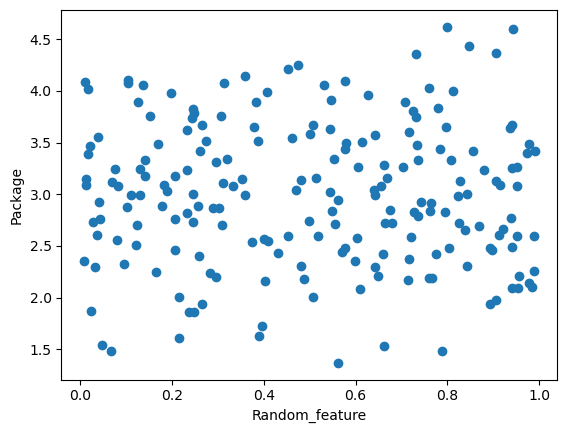

In [65]:
plt.scatter(new_df1['random_feature'], new_df1['package'])
plt.xlabel('Random_feature')
plt.ylabel('Package')

In [66]:
x = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]


In [77]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=2)

In [78]:
lr1 = LinearRegression()

In [79]:
lr1.fit(x_train,y_train)

LinearRegression()

In [80]:
y_pred1 = lr1.predict(x_test)

In [83]:
r2 = r2_score(y_test,y_pred1)
r2

0.7795190509706462

In [85]:
1-(((1-r2)*(40-1))/(40-1-2))

0.7676011618339244

In [86]:
df2 = df.copy()

In [87]:
df2['iq'] = df2['package']+(np.random.randint(-12,12,200)/10)

In [88]:
df2

,cgpa,package,iq
0,6.89,3.26,2.36
1,5.12,1.98,1.68
2,7.82,3.25,3.05
3,7.42,3.67,4.47
4,6.94,3.57,3.87
...,...,...,...
195,6.93,2.46,2.06
196,5.89,2.57,3.57
197,7.21,3.24,2.84
198,7.63,3.96,3.66


In [89]:
df2 = df2[['cgpa', 'iq', 'package']]

In [90]:
df2

,cgpa,iq,package
0,6.89,2.36,3.26
1,5.12,1.68,1.98
2,7.82,3.05,3.25
3,7.42,4.47,3.67
4,6.94,3.87,3.57
...,...,...,...
195,6.93,2.06,2.46
196,5.89,3.57,2.57
197,7.21,2.84,3.24
198,7.63,3.66,3.96


Text(0, 0.5, 'Package')

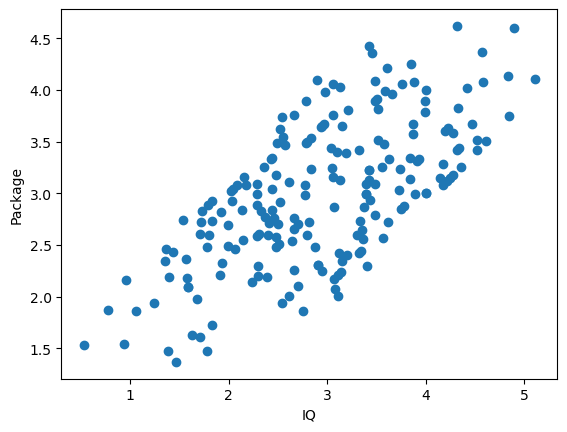

In [91]:
plt.scatter(df2['iq'], df2['package'])
plt.xlabel('IQ')
plt.ylabel('Package')

In [92]:
x = df2.iloc[:,0:2]
y = df2.iloc[:,-1]

In [93]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=2)

In [94]:
lr = LinearRegression()

In [97]:
lr.fit(x_train,y_train)

LinearRegression()

In [98]:
y_pred = lr.predict(x_test)

In [99]:
r2 = r2_score(y_test,y_pred)
r2

0.8100753964741814

In [100]:
1-((1-r2)*(40-1))/(40-1-2)

0.7998092016890019